In [1]:
# Reprodubility test

In [2]:
# !pip install gdown
# import gdown

# url = "https://drive.google.com/drive/folders/1HQmDqBODEFtEEtJhnqI1-f9CKEP48A3Y?usp=sharing"
# gdown.download_folder(url)

In [3]:
# %%capture
# !pip install unsloth
# # Also get the latest nightly Unsloth!
# !pip uninstall unsloth -y && pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install -U jarvis-tools
# !pip install pymatgen


In [4]:
# from jarvis.db.jsonutils import loadjson, dumpjson
# from jarvis.db.figshare import data
# from jarvis.db.jsonutils import loadjson, dumpjson
# from unsloth import FastLanguageModel
# from sklearn.model_selection import train_test_split
# import json

In [3]:
from jarvis.db.figshare import data
from datasets import load_dataset
from utils import make_alpaca_json, formatting_prompts_func,eval_prompts
from models import load_model, get_model, get_trainer, save_model
from jarvis.db.jsonutils import loadjson, dumpjson
from unsloth import FastLanguageModel
from datasets import Dataset
from sample_funcs import generate_sample
import torch

/home/jipengsun/.conda/envs/llm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


In [6]:
#from pure
fourbit_models = [
        "unsloth/tinyllama-bnb-4bit", #X
        "unsloth/mistral-7b-bnb-4bit", #X
        "unsloth/mistral-7b-instruct-v0.2-bnb-4bit", #X
        "unsloth/llama-2-7b-bnb-4bit",  #X
        "unsloth/gemma-7b-bnb-4bit", #X
        "unsloth/llama-3-8b-bnb-4bit", #X 
        "unsloth/llama-2-13b-bnb-4bit", #X
        "unsloth/codellama-34b-bnb-4bit", #X
        "unsloth/llama-3-70b-bnb-4bit",
]  # More models at https://huggingface.co/unsloth
    
# fourbit_models = fourbit_models[args.model]
fourbit_models = fourbit_models[5]   
print("Models Name", fourbit_models)
# from pretrained 
model, tokenizer = load_model(fourbit_models.split("/")[1]) #/home/jipengsun/atom-gen/meta-llama
        
FastLanguageModel.for_inference(model)  # Enable native 2x faster inference
    
try:
    data_train = load_dataset("json", data_files="./data/optb88vdw_bandgap_train.json", split="train")
    data_test = load_dataset("json", data_files="./data/optb88vdw_bandgap_test.json", split="train")
    #data_val = load_dataset("json", data_files="./data/alpaca_Tc_supercon_val.json", split="train")
except Exception as e:
    print(e)

Models Name unsloth/llama-3-8b-bnb-4bit


==((====))==  Unsloth 2024.9: Fast Llama patching. Transformers = 4.44.2.
   \\   /|    GPU: Quadro RTX 8000. Max memory: 44.481 GB. Platform = Linux.
O^O/ \_/ \    Pytorch: 2.4.1. CUDA = 7.5. CUDA Toolkit = 12.1.
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.28.post1. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth


Unsloth 2024.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [7]:
data_train = data_train.add_column("prompt", eval_prompts(data_train))

In [10]:
def ge_samples(data, model, tokenizer, model_name):
    data = data["prompt"][10]
    batch = tokenizer(data, return_tensors="pt")
    batch = {k: v.cuda() for k, v in batch.items()}
    generate_ids = model.generate(
                **batch,
                do_sample=True,
                max_new_tokens=256,
                pad_token_id=tokenizer.eos_token_id,
                use_cache=True)

    gen_strs = tokenizer.batch_decode(
                    generate_ids, 
                    skip_special_tokens=True, 
                    clean_up_tokenization_spaces=True
                )
    for gen_str in (gen_strs):
            material_str = gen_str.replace(data, "")
    print("____")
    print(material_str)

In [11]:
ge_samples(data_train, model, tokenizer, fourbit_models)

____
7.7 7.7 7.7
110 110 106
Nd
0.12 0.75 0.87
Nd
0.25 0.62 0.37
Nd
0.38 0.25 0.63
Nd
0.75 0.88 0.13
Cd
0.63 0.38 0.25
Cd
0.88 0.13 0.75
Se
0.01 0.88 0.51
Se
0.99 0.37 0.49
Se
0.49 0.01 0.87
Se
0.12 0.13 0.13
Se
0.38 0.51 0.01
Se
0.63 0.62 0.63
Se
0.51 0.99 0.37
Se
0.87 0.49 0.99


In [12]:
ge_samples(data_train, model, tokenizer, fourbit_models)

____
7.7 7.7 7.7
110 110 106
Nd
0.12 0.75 0.87
Nd
0.25 0.62 0.37
Nd
0.38 0.25 0.63
Nd
0.75 0.88 0.13
Cd
0.63 0.38 0.25
Cd
0.88 0.13 0.75
Se
0.01 0.88 0.51
Se
0.99 0.37 0.49
Se
0.49 0.01 0.87
Se
0.12 0.13 0.13
Se
0.38 0.51 0.01
Se
0.63 0.62 0.63
Se
0.51 0.99 0.37
Se
0.87 0.49 0.99


In [13]:
ge_samples(data_train, model, tokenizer, fourbit_models)

____
7.7 7.7 7.7
110 110 106
Nd
0.12 0.75 0.87
Nd
0.25 0.62 0.37
Nd
0.38 0.25 0.63
Nd
0.75 0.88 0.13
Cd
0.62 0.38 0.25
Cd
0.88 0.12 0.75
Se
0.01 0.88 0.51
Se
0.49 0.00 0.87
Se
0.12 0.13 0.13
Se
0.38 0.51 0.01
Se
0.63 0.62 0.63
Se
0.50 0.99 0.37
Se
0.87 0.50 0.99
Se
1.00 0.37 0.49


In [14]:
ge_samples(data_train, model, tokenizer, fourbit_models)

____
7.7 7.7 7.7
110 110 106
Nd
0.12 0.75 0.87
Nd
0.25 0.62 0.37
Nd
0.38 0.25 0.63
Nd
0.75 0.88 0.13
Cd
0.62 0.38 0.25
Cd
0.88 0.13 0.75
Se
0.99 0.37 0.49
Se
0.51 0.99 0.37
Se
0.12 0.13 0.13
Se
0.38 0.51 0.01
Se
0.49 0.01 0.87
Se
0.63 0.62 0.63
Se
0.01 0.88 0.51
Se
0.87 0.49 0.99


In [4]:
dft_3d = data("dft_3d")
print(len(dft_3d))

Obtaining 3D dataset 76k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...


Loading completed.
75993


In [5]:
import pandas as pd
df = pd.DataFrame(dft_3d)

In [6]:
df

,jid,spg_number,spg_symbol,formula,formation_energy_peratom,func,optb88vdw_bandgap,atoms,slme,magmom_oszicar,...,density,poisson,raw_files,nat,bulk_modulus_kv,shear_modulus_gv,mbj_bandgap,hse_gap,reference,search
0,JVASP-90856,129,P4/nmm,TiCuSiAs,-0.42762,OptB88vdW,0.000,"{'lattice_mat': [[3.566933224304235, 0.0, -0.0...",na,0.0,...,5.956,na,[],8,na,na,na,na,mp-1080455,-As-Cu-Si-Ti
1,JVASP-86097,221,Pm-3m,DyB6,-0.41596,OptB88vdW,0.000,"{'lattice_mat': [[4.089078911208881, 0.0, 0.0]...",na,0.0,...,5.522,na,"[OPT-LOPTICS,JVASP-86097.zip,https://ndownload...",7,na,na,na,na,mp-568319,-B-Dy
2,JVASP-64906,119,I-4m2,Be2OsRu,0.04847,OptB88vdW,0.000,"{'lattice_mat': [[-1.833590720595598, 1.833590...",na,0.0,...,10.960,na,"[OPT-LOPTICS,JVASP-64906.zip,https://ndownload...",4,na,na,na,na,auid-3eaf68dd483bf4f4,-Be-Os-Ru
3,JVASP-98225,14,P2_1/c,KBi,-0.44140,OptB88vdW,0.472,"{'lattice_mat': [[7.2963518353359165, 0.0, 0.0...",na,0.0,...,5.145,na,[],32,na,na,na,na,mp-31104,-Bi-K
4,JVASP-10,164,P-3m1,VSe2,-0.71026,OptB88vdW,0.000,"{'lattice_mat': [[1.6777483798834445, -2.90594...",na,0.0,...,5.718,0.23,"[FD-ELAST,JVASP-10.zip,https://ndownloader.fig...",3,48.79,33.05,0.0,na,mp-694,-Se-V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75988,JVASP-156020,139,I4/mmm,AcRh2Pb2,-0.30652,OptB88vdW,0.000,"{'lattice_mat': [[-2.374509402119681, 2.374509...",na,0.0,...,11.194,na,[],5,na,na,na,na,1206834,-Ac-Pb-Rh
75989,JVASP-156398,216,F-43m,PrTlZn,-0.34112,OptB88vdW,0.000,"{'lattice_mat': [[-0.0, 3.4210598347774503, 3....",na,0.0,...,8.517,na,[],3,na,na,na,na,915022,-Pr-Tl-Zn
75990,JVASP-156099,139,I4/mmm,BaIn2Bi2,-0.39352,OptB88vdW,0.000,"{'lattice_mat': [[4.082347574975881, -4.076131...",na,0.0,...,7.460,0.67,[],5,30.67,-11.44,na,na,1214095,-Ba-Bi-In
75991,JVASP-156007,139,I4/mmm,TmSi2Tc2,-0.54853,OptB88vdW,0.000,"{'lattice_mat': [[2.90400678672412, -2.9037689...",na,0.0,...,8.212,na,[],5,na,na,na,na,1206745,-Si-Tc-Tm


In [7]:
filtered_df = df[df['optb88vdw_bandgap'] > 0]
len(filtered_df)

23061

In [12]:
filtered_df['optb88vdw_bandgap'].max()

18.179

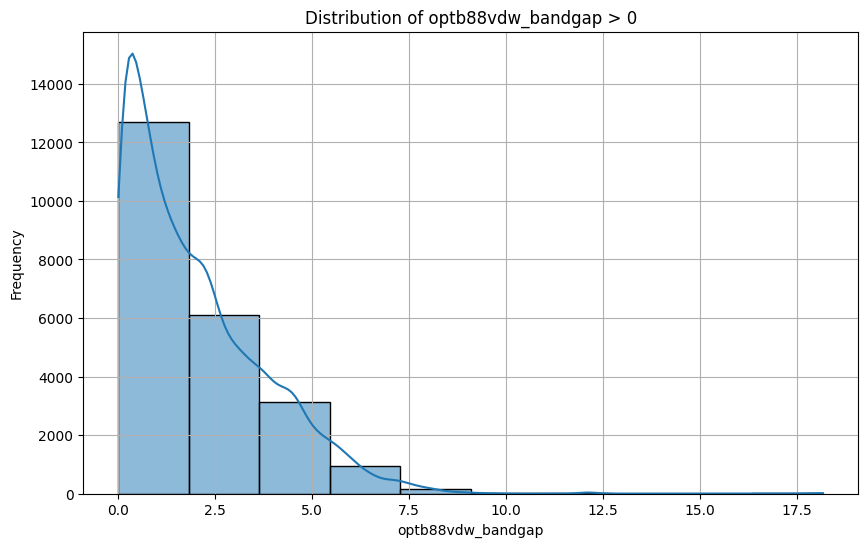

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['optb88vdw_bandgap'], bins=10, kde=True)

plt.title('Distribution of optb88vdw_bandgap > 0')
plt.xlabel('optb88vdw_bandgap')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

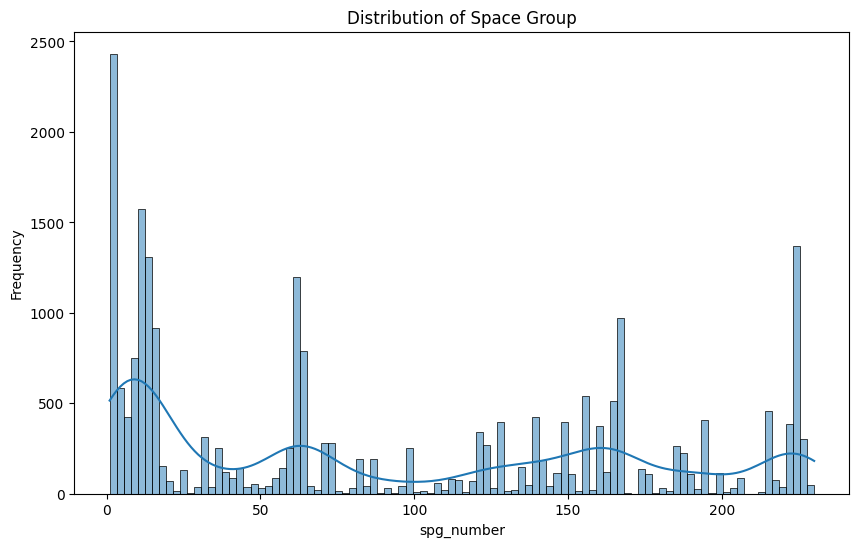

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['spg_number'].astype(int), bins=100, kde=True)

plt.title('Distribution of Space Group')
plt.xlabel('spg_number')
plt.ylabel('Frequency')

#plt.grid(True)
plt.show()

In [30]:
filtered_df['spg_number']

3         14
9        156
10       166
15       162
19       156
        ... 
75903    164
75912    216
75930     63
75949    164
75961    216
Name: spg_number, Length: 23061, dtype: object

In [1]:
from jarvis.core.atoms import Atoms


In [8]:
atoms = filtered_df['atoms'].apply(Atoms.from_dict)

In [9]:
lenghts = atoms.apply(lambda x: x.lattice.abc)
lenghts

3          [7.29635, 13.439606, 14.224693]
9            [3.22505, 3.225043, 34.14068]
10       [10.149727, 10.149727, 10.149728]
15            [4.92723, 4.927231, 4.90787]
19           [3.29213, 3.292143, 34.97825]
                       ...                
75903         [4.74142, 4.741418, 7.60968]
75912       [4.674485, 4.674485, 4.674485]
75930        [6.615646, 6.615646, 5.77978]
75949         [4.72446, 4.724459, 7.47041]
75961       [4.551166, 4.551166, 4.551166]
Name: atoms, Length: 23061, dtype: object

In [21]:
filtered_df[['Column 1', 'Column 2', 'Column 3']] = lenghts.apply(pd.Series)

/tmp/ipykernel_306728/4161647175.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[['Column 1', 'Column 2', 'Column 3']] = lenghts.apply(pd.Series)


3         7.296350
9         3.225050
10       10.149727
15        4.927230
19        3.292130
           ...    
75903     4.741420
75912     4.674485
75930     6.615646
75949     4.724460
75961     4.551166
Name: Column 1, Length: 23061, dtype: float64

In [23]:
import matplotlib.pyplot as plt


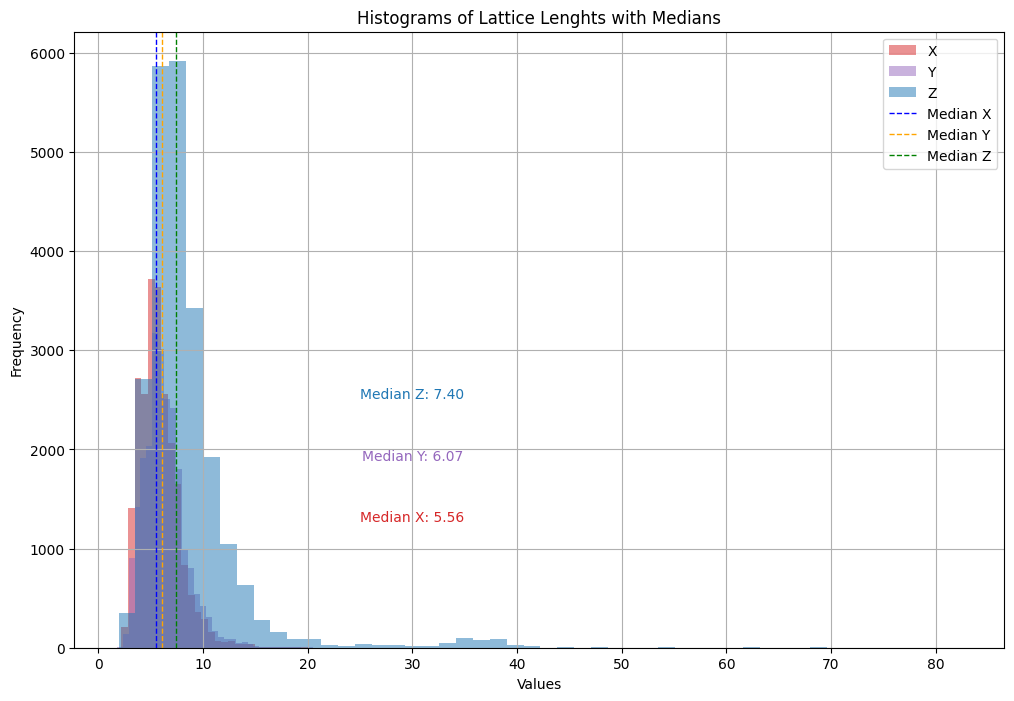

In [53]:
# Plotting histograms
plt.figure(figsize=(12, 8))

plt.hist(filtered_df['Column 1'], bins=50, alpha=0.5, label='X', color='#d62728')
plt.hist(filtered_df['Column 2'], bins=50, alpha=0.5, label='Y', color='#9467bd')
plt.hist(filtered_df['Column 3'], bins=50, alpha=0.5, label='Z', color='#1f77b4')

# Calculate medians
median_x = filtered_df['Column 1'].median()
median_y = filtered_df['Column 2'].median()
median_z = filtered_df['Column 3'].median()

# Adding median lines
plt.axvline(median_x, color='blue', linestyle='dashed', linewidth=1, label='Median X')
plt.axvline(median_y, color='orange', linestyle='dashed', linewidth=1, label='Median Y')
plt.axvline(median_z, color='green', linestyle='dashed', linewidth=1, label='Median Z')

max_y = plt.ylim()[1]  # Get the maximum y limit

# Adding median value annotations with adjusted y positions
plt.text(30, max_y * 0.2, f'Median X: {median_x:.2f}', color='#d62728', 
         verticalalignment='bottom', horizontalalignment='center', fontsize=10)
plt.text(30, max_y * 0.3, f'Median Y: {median_y:.2f}', color='#9467bd', 
         verticalalignment='bottom', horizontalalignment='center', fontsize=10)
plt.text(30, max_y * 0.4, f'Median Z: {median_z:.2f}', color='#1f77b4', 
         verticalalignment='bottom', horizontalalignment='center', fontsize=10)


# Adding titles and labels
plt.title('Histograms of Lattice Lenghts with Medians')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()  # Show the legend
plt.grid(True)

# Show the plot
plt.show()

In [54]:
elements = atoms.apply(lambda x: x.elements)
elements

3        [K, K, K, K, K, K, K, K, K, K, K, K, K, K, K, ...
9                  [Mo, W, W, W, Se, Se, S, S, S, S, S, S]
10       [Ba, Ba, Ba, Ba, Ce, Mn, Mn, Mn, O, O, O, O, O...
15                          [Cd, As, As, O, O, O, O, O, O]
19           [Mo, Mo, Mo, W, Se, Se, Se, Se, Se, Se, S, S]
                               ...                        
75903                                 [Mg, Mg, Sb, Sb, Pb]
75912                                         [Th, Ge, Pd]
75930                     [Ba, Ba, Pd, Pd, Se, Se, Se, Se]
75949                                 [Mg, Mg, Sn, Sb, Sb]
75961                                         [Hf, Pd, Pb]
Name: atoms, Length: 23061, dtype: object

In [67]:
unique_counts = elements.apply(lambda row: (set(row)))
unique_counts

3                {K, Bi}
9         {W, Se, Mo, S}
10       {Ce, Ba, Mn, O}
15           {Cd, O, As}
19        {W, Se, Mo, S}
              ...       
75903       {Pb, Sb, Mg}
75912       {Th, Pd, Ge}
75930       {Ba, Se, Pd}
75949       {Sn, Sb, Mg}
75961       {Hf, Pd, Pb}
Name: atoms, Length: 23061, dtype: object

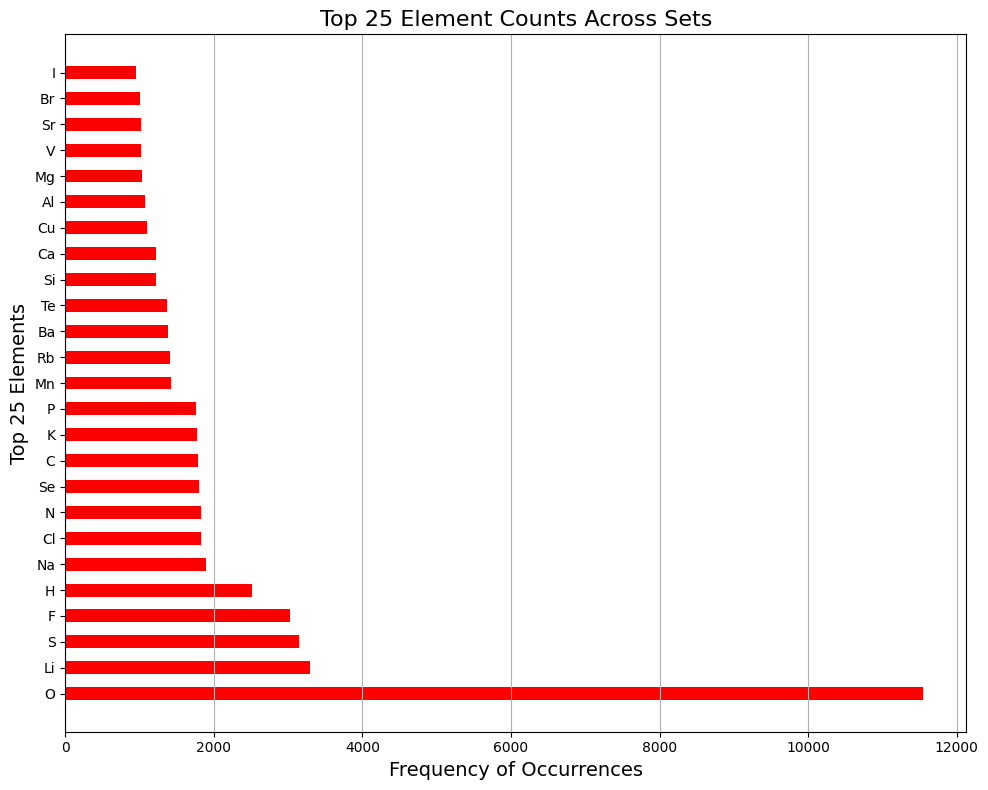

In [129]:
from collections import Counter

element_counts = Counter()

for s in unique_counts:
    element_counts.update(s)


elements = list(element_counts.keys())
counts = list(element_counts.values())

# Sort elements and counts based on counts
sorted_counts, sorted_elements = zip(*sorted(zip(counts, elements), reverse=True))

top_n = 25
sorted_counts = sorted_counts[:top_n]
sorted_elements = sorted_elements[:top_n]

# Plotting the counts as a horizontal bar chart
plt.figure(figsize=(10, 8))  # Increase figure height for better spacing
plt.barh(sorted_elements, sorted_counts, color='red', height=0.5)  # Adjust bar height for spacing
plt.ylabel('Top 25 Elements', fontsize=14)  # Updated y-label
plt.xlabel('Frequency of Occurrences', fontsize=14)  # Updated x-label
plt.title('Top 25 Element Counts Across Sets', fontsize=16)
plt.grid(axis='x')
# Rotate x-ticks for better visibility
plt.xticks(rotation=0)

# Set x-axis limits to extend the space between bars

# Adjust layout to prevent clipping of tick-labels
plt.tight_layout()

# Show the plot
plt.show()

In [122]:
len(sorted_elements)

89